# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [2]:
# =============================
# Useful Imports
# =============================

# Standard Libraries

!pip install numpy pandas seaborn scikit-learn tqdm

import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [3]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [4]:
df.head

<bound method NDFrame.head of        parcelid  airconditioningtypeid  architecturalstyletypeid  \
0      14297519                    NaN                       NaN   
1      17052889                    NaN                       NaN   
2      14186244                    NaN                       NaN   
3      12177905                    NaN                       NaN   
4      10887214                    1.0                       NaN   
...         ...                    ...                       ...   
77608  10833991                    1.0                       NaN   
77609  11000655                    NaN                       NaN   
77610  17239384                    NaN                       NaN   
77611  12773139                    1.0                       NaN   
77612  12826780                    NaN                       NaN   

       basementsqft  bathroomcnt  bedroomcnt  buildingclasstypeid  \
0               NaN          3.5         4.0                  NaN   
1              

In [5]:
df.info

<bound method DataFrame.info of        parcelid  airconditioningtypeid  architecturalstyletypeid  \
0      14297519                    NaN                       NaN   
1      17052889                    NaN                       NaN   
2      14186244                    NaN                       NaN   
3      12177905                    NaN                       NaN   
4      10887214                    1.0                       NaN   
...         ...                    ...                       ...   
77608  10833991                    1.0                       NaN   
77609  11000655                    NaN                       NaN   
77610  17239384                    NaN                       NaN   
77611  12773139                    1.0                       NaN   
77612  12826780                    NaN                       NaN   

       basementsqft  bathroomcnt  bedroomcnt  buildingclasstypeid  \
0               NaN          3.5         4.0                  NaN   
1            

In [6]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [7]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Unique Values": df.nunique().values,
    "Missing Values": df.isnull().sum().values})

summary["Percent Missing"] = (summary["Missing Values"] / len(df)) * 100

summary

,Column,Data Type,Unique Values,Missing Values,Percent Missing
0,parcelid,int64,77414,0,0.000000
1,airconditioningtypeid,float64,5,52606,67.779882
2,architecturalstyletypeid,float64,5,77406,99.733292
3,basementsqft,float64,43,77563,99.935578
4,bathroomcnt,float64,22,34,0.043807
5,bedroomcnt,float64,16,34,0.043807
6,buildingclasstypeid,float64,2,77598,99.980673
7,buildingqualitytypeid,float64,12,27804,35.823895
8,calculatedbathnbr,float64,21,650,0.837489
9,decktypeid,float64,1,76999,99.208895


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

**categorical (object or strings above):**

hashottuborspa:  presence of hot tub/spa
propertycountylanduse code:   land use classification
propertyzoningdesc:  zoning description
fireplaceflag:   presence of fireplace
taxdelinquencyflag:   tax delinquincy status

many **numeric features** with a small number of unique values above are likely categorical becuase they are indentifiers or codes.   may require encoding before used later in modeling:

property and building identifiers:

aircondiioningtypeid
aichitecturalstyletypeid
buildingclasstypeid
typeconstructiontypeid
propertylandusetypeid
heatingorsystemtypeid
decktypeid
storytypeid

pool related identifiers:

poolcnt
pooltypeid10
pooltypeid2
pooltypeid7

location identifiers:

fips
regionidcity
regionidcounty
regionidneighborhood
regionidzip


**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

parcel id appears useless becuase it is simply a unique identifier for labeling property.

some features such may be redundant and may need more investigating to determine how related they are and maybe some need to be dropped to avoid multicollinearity, such as multiple versions of square footage:  finishedsqarefeet12, finishedsqarefeet15, calculatedfinishedsqarefeet, etc.

after reviewing the appendix of columns some of the pool features may be redundant and provide no extra value.   for instance pooltypeid10 is just a binary indicator for presence of spa/hot tub, same as with pooltypeid2 is just a binary indicator for presence of pool with a spa/hot tub, same as with pooltypeid7 is just a binary indicator for presence of pool without spa/hot tub.   as well as these features being very sparse (with 99% missing) they are also likely redundant with the feature poolcount.   if poolcount is greater than zero you already know there is a pool.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

some features appear to have a high number of missing values and are unlikely to provide enough signal to be useful and will be hard to impute that many missing values.  some examples include:  architecturaltypeid, basementsqft, storytypeid

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

some features contain only 1 unique value along with a high percent of missing values.  there is no meaningful data for the model to learn from.   for example storytypeid and fireplaceflag both have 1 unique value and the rest of the rows are empty.

on the flip side latitude and longitude have so many unique (over 60k) values (high cardinality) that it may be hard to use them without some sort of transformation first.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

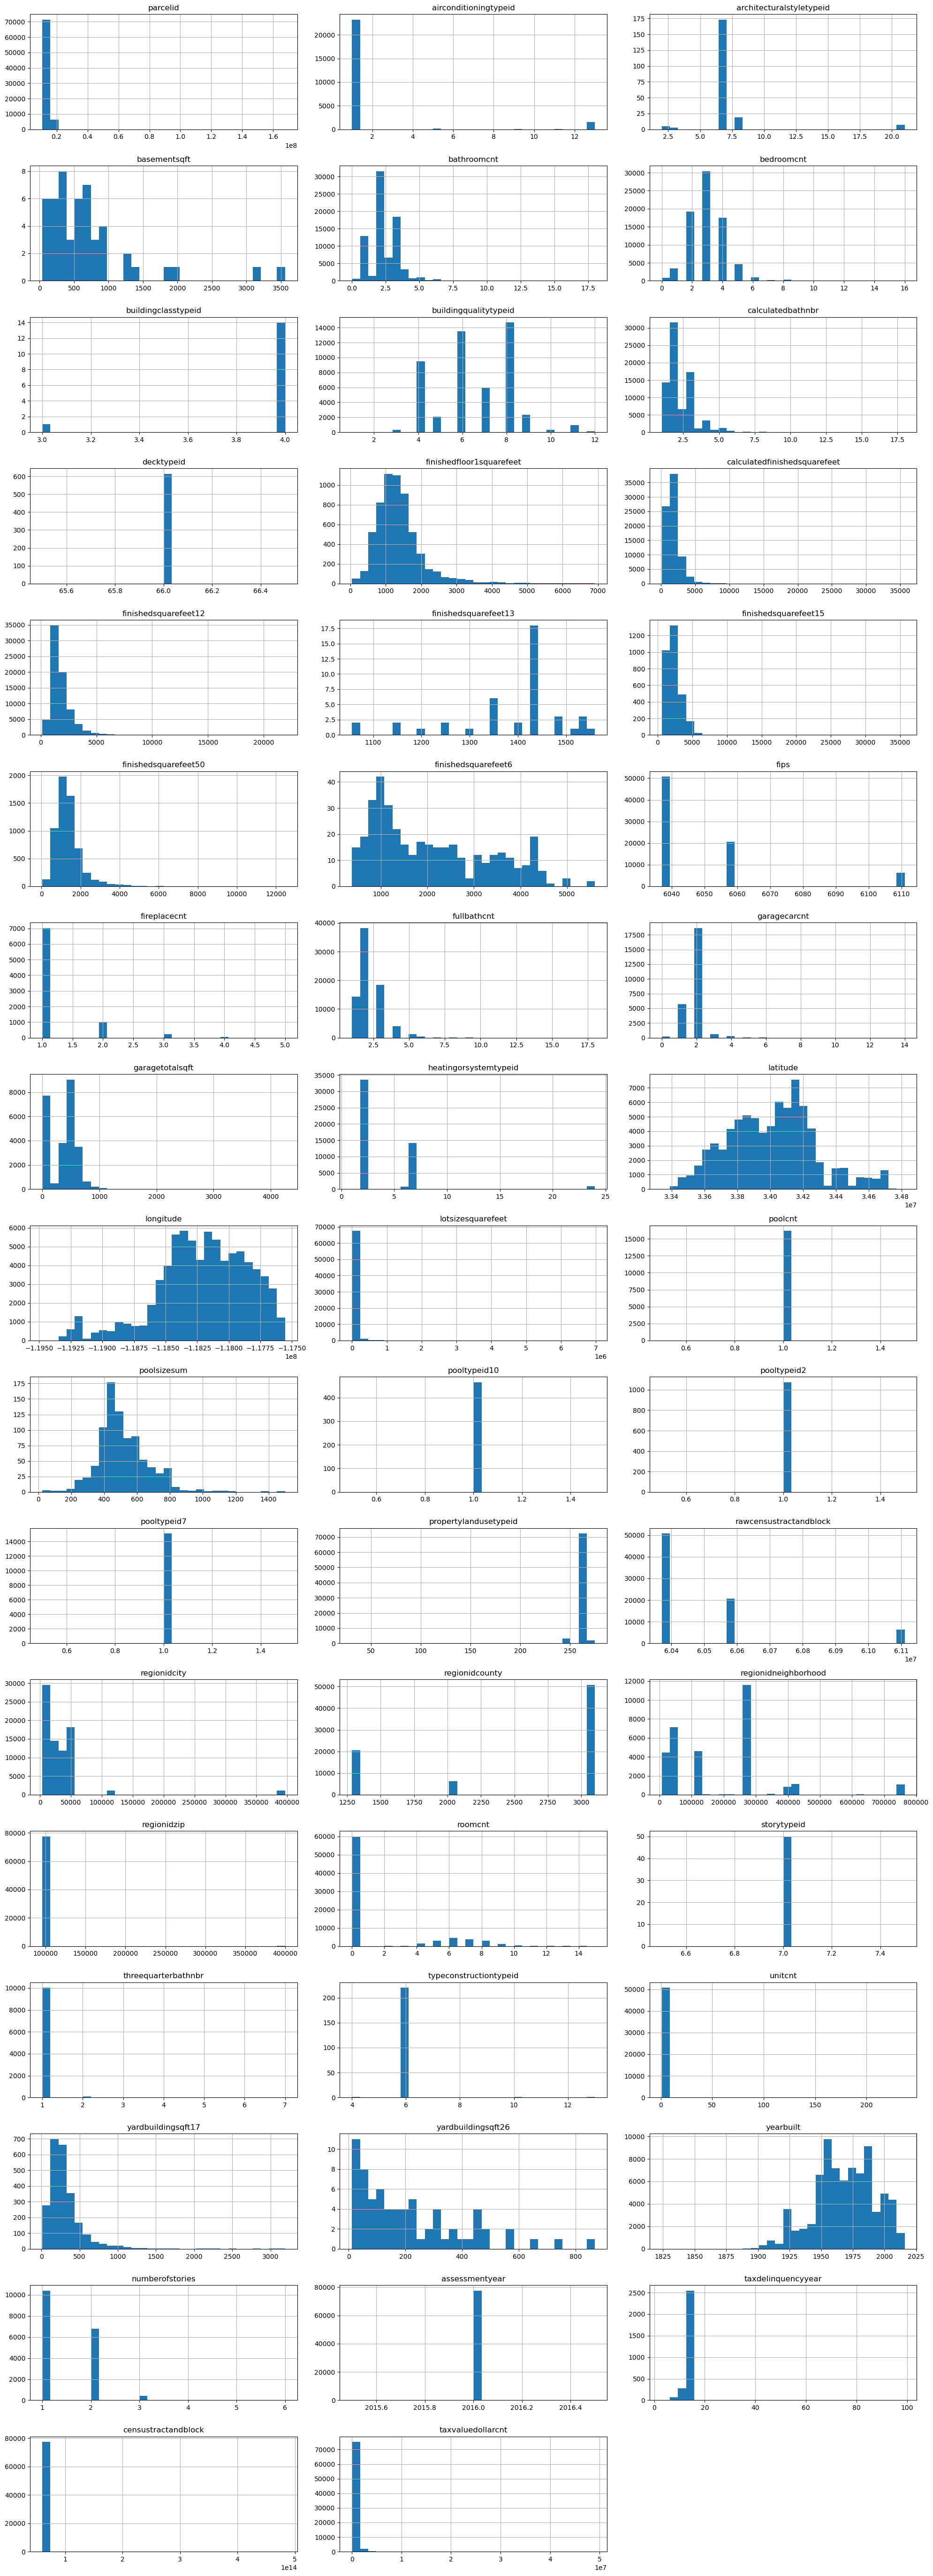

In [8]:
df.hist(figsize=(20, 55), bins=30, layout=(-1, 3))
plt.tight_layout()
plt.show()

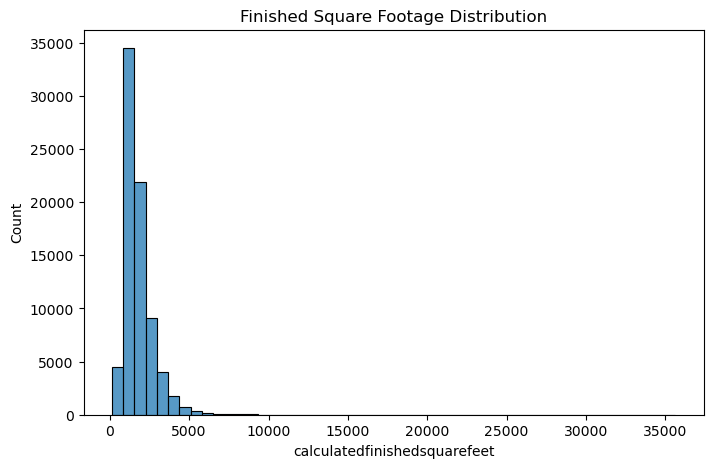

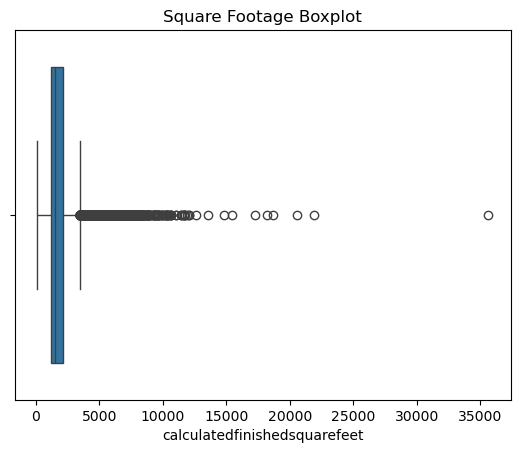

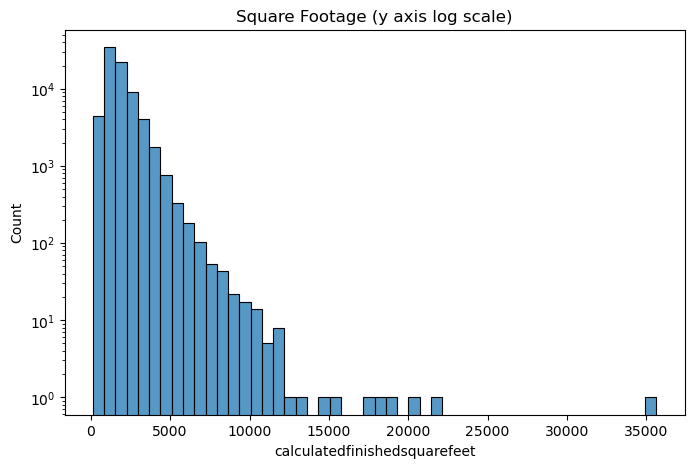

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['calculatedfinishedsquarefeet'], bins=50)
plt.title("Finished Square Footage Distribution")
plt.show()

sns.boxplot(x=df['calculatedfinishedsquarefeet'])
plt.title("Square Footage Boxplot")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['calculatedfinishedsquarefeet'], bins=50)
plt.yscale('log')
plt.title("Square Footage (y axis log scale)")
plt.show()

The feature calculatedfinishedsqarefeet is likely to be an important indicator in any modeling we due as in general homes with more square feet will have higher sale prices.

As seen in the histogram and box plot above the distribution of this feature is right skewed.   The majority of the properties are between 500-3000 sqft and there is a long right tail that is very obvious in the box plot as seen by the extended whiskers to the right.  These outliers likely correspnd to luxury homes and could affect our modeling downstream.  It may be beneficial to apply a log transformation.

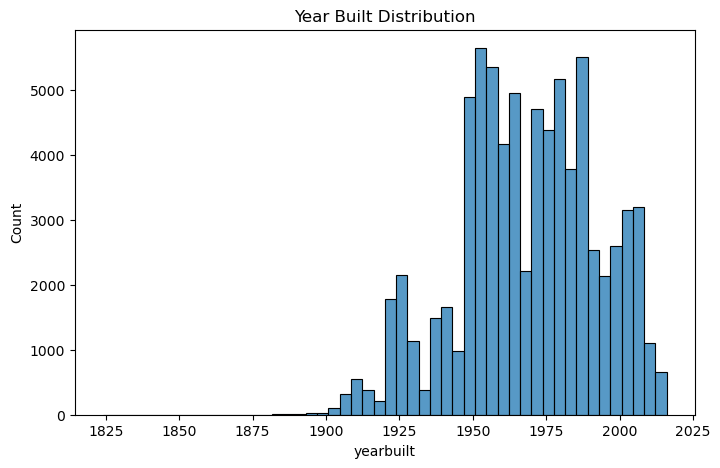

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['yearbuilt'], bins=50)
plt.title("Year Built Distribution")
plt.show()



Distribution of **yearbuilt** shows that most homes were built between ~1950-2000.  there is an interesting small bin around 1973....perhaps the 1973 oil embargo caused a housing dip?  there are relatively few homes built before 1920 as well as a slight dip in new homes after 2010.  Data does not appear highly skewed unlike some other features.  Newer homes usually differ in quality and amenities as compared to older homes.   this feature may be informative for predicting home values.

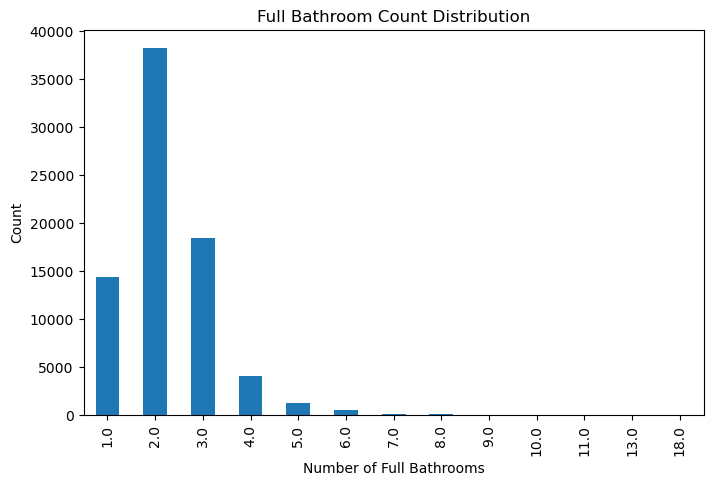

In [11]:
bath_counts = df['fullbathcnt'].value_counts().sort_index()

plt.figure(figsize=(8,5))
bath_counts.plot(kind='bar')

plt.title("Full Bathroom Count Distribution")
plt.xlabel("Number of Full Bathrooms")
plt.ylabel("Count")

plt.show()

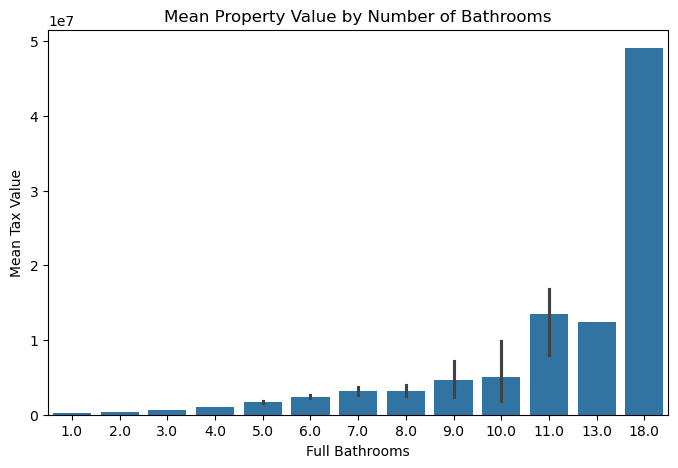

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x='fullbathcnt', y='taxvaluedollarcnt', data=df, estimator=np.mean)

plt.title("Mean Property Value by Number of Bathrooms")
plt.xlabel("Full Bathrooms")
plt.ylabel("Mean Tax Value")

plt.show()

The distribution of **fullbathcnt** shows that most homes have 2 or 3 full baths.  the distribution is right skewed with a long right tail seen in the first of the 2 figures above.  This right tail is likely luxury homes with many bathrooms or other outliers.  As seen in the second of the two figures abvoe there appears to be a positive relationship between number of full baths and increased property value as the mean property value is seen increasing as the umber of full baths increase.  Notice the large error bars as the mean gets bigger.   The large homes vary a lot in price and also there aren't many large homes so the error bar is wide.  Perhaps the median price should be used instead of the average price so it wouldn't be so sensitive to outliers among the luxury homes.

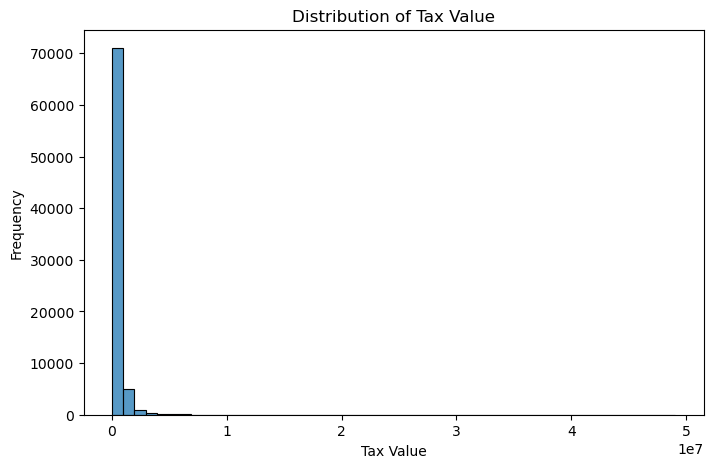

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['taxvaluedollarcnt'], bins=50)
plt.title("Distribution of Tax Value")
plt.xlabel("Tax Value")
plt.ylabel("Frequency")
plt.show()

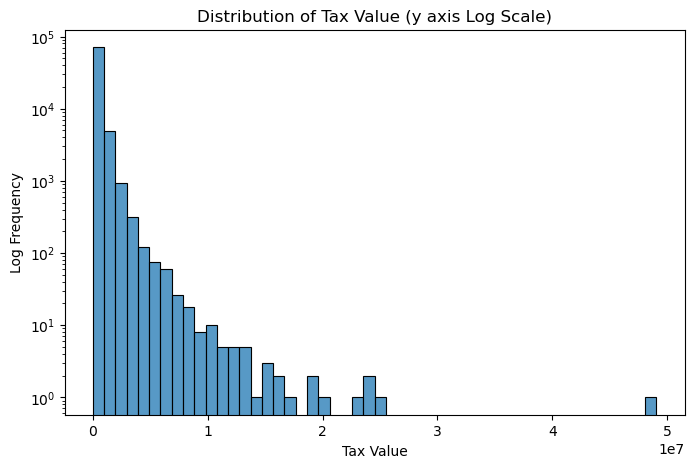

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['taxvaluedollarcnt'], bins=50)

plt.yscale('log')  # 🔑 log scale on y-axis

plt.title("Distribution of Tax Value (y axis Log Scale)")
plt.xlabel("Tax Value")
plt.ylabel("Log Frequency")

plt.show()

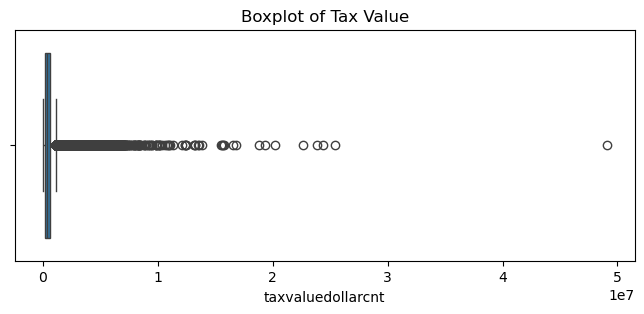

In [15]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['taxvaluedollarcnt'])
plt.title("Boxplot of Tax Value")
plt.show()

The target variable **taxvaluedollarcnt** is highly right skewed.   The majority of the values are concentrated at the lower end as well as a long tail extending to the right.  this is seen clearly when you apply a log scale to the y axis of the histogram as well as the extended whiskers to the right in the box plot.  The extreme values found in the right tail may negatively impact model performace and may be beneficial to apply a log tranformation.

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


**For 2.B see the discussion of each set of figures below each set in the sections above.**

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [16]:
# ── Part 3.A: Drop features unsuitable for the regression task ────────────────

cols_to_drop_3a = [
    'parcelid',                   # Unique row ID — no predictive signal whatsoever
    'assessmentyear',             # Near-constant field; year of assessment doesn't predict value
    'rawcensustractandblock',     # Near-unique composite geographic code, redundant with regionid* cols
    'censustractandblock',        # Same composite code, different format — still redundant
    'propertycountylandusecode',  # High-cardinality string (hundreds of unordered county codes)
    'propertyzoningdesc',         # Free-text zoning description — unusable without NLP / domain expertise
]

# Guard against columns already removed
cols_to_drop_3a = [c for c in cols_to_drop_3a if c in df.columns]
df_3a = df.drop(columns=cols_to_drop_3a)

print(f"Dropped {len(cols_to_drop_3a)} columns in 3.A:")
for c in cols_to_drop_3a:
    print(f"  - {c}")
print(f"\nShape:  {df.shape}  →  {df_3a.shape}")


Dropped 6 columns in 3.A:
  - parcelid
  - assessmentyear
  - rawcensustractandblock
  - censustractandblock
  - propertycountylandusecode
  - propertyzoningdesc

Shape:  (77613, 55)  →  (77613, 49)


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop.

We dropped six columns that are conceptually useless for predicting assessed property value, independent of any data quality concerns. `parcelid` is a unique administrative identifier assigned per row — it carries no information about what the property is worth and would simply memorize training examples if kept. `assessmentyear` is effectively a constant field (all records come from the same assessment cycle), so it contributes zero variance and no predictive signal. `rawcensustractandblock` and `censustractandblock` are both composite geographic identifiers that combine census tract and block numbers into a single large integer; they are nearly unique per property and entirely redundant with the more interpretable `regionidcity`, `regionidzip`, and `regionidcounty` columns. Finally, `propertycountylandusecode` and `propertyzoningdesc` are high-cardinality string fields with hundreds of distinct codes and free-text zoning descriptions — encoding them into a large number of dummy variables would introduce enormous dimensionality, and without deep domain knowledge of county-level land-use taxonomy, they would add noise rather than signal to a general regression model.


### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [17]:
# ── Part 3.B: Drop features with "too many" missing values ───────────────────
# Threshold: drop any feature missing in more than 60% of rows.
# Reasoning: imputing >60% of a column means we're mostly inventing data,
# which introduces noise rather than signal for any model.

MISSING_THRESHOLD = 0.60

missing_frac_3b = df_3a.isnull().mean().sort_values(ascending=False)
cols_to_drop_3b = missing_frac_3b[missing_frac_3b > MISSING_THRESHOLD].index.tolist()

print(f"Features exceeding {MISSING_THRESHOLD*100:.0f}% missing ({len(cols_to_drop_3b)} columns):\n")
display(
    missing_frac_3b[missing_frac_3b > MISSING_THRESHOLD]
    .to_frame('Missing Fraction')
    .style.format('{:.1%}')
)

df_3b = df_3a.drop(columns=cols_to_drop_3b)
print(f"\nShape:  {df_3a.shape}  →  {df_3b.shape}")
print(f"Remaining features: {df_3b.shape[1]}")


Features exceeding 60% missing (29 columns):



,Missing Fraction
buildingclasstypeid,100.0%
finishedsquarefeet13,99.9%
storytypeid,99.9%
basementsqft,99.9%
yardbuildingsqft26,99.9%
fireplaceflag,99.8%
architecturalstyletypeid,99.7%
typeconstructiontypeid,99.7%
finishedsquarefeet6,99.5%
pooltypeid10,99.4%



Shape:  (77613, 49)  →  (77613, 20)
Remaining features: 20


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped

We applied a threshold of **60% missing values** to decide which features to drop. Any column missing for more than 60% of properties was removed, because at that level of sparsity, imputing the remaining values would mean manufacturing data for the majority of rows — introducing far more noise than signal. The dropped columns are consistent with our Part 2.A findings: features like `basementsqft`, `architecturalstyletypeid`, `buildingclasstypeid`, `decktypeid`, `finishedsquarefeet13`, `finishedsquarefeet50`, `finishedsquarefeet6`, `storytypeid`, `typeconstructiontypeid`, `yardbuildingsqft17`, `yardbuildingsqft26`, `fireplaceflag`, `taxdelinquencyflag`, and `taxdelinquencyyear` are all extremely sparse. Many of these represent rare property features (basements, decks, unusual construction types) that simply aren't recorded for the overwhelming majority of residential properties in the dataset. Keeping them would produce mostly-constant columns after imputation. The 60% cutoff was chosen to be conservative enough to preserve features like `poolcnt`, `fireplacecnt`, and `garagecarcnt` which, while somewhat sparse, still cover enough of the dataset to be informative for value estimation.


### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [18]:
# ── Part 3.C: Drop problematic samples ───────────────────────────────────────

df_3c = df_3b.copy()

# Step 1: Drop rows where the TARGET is null — we cannot learn from them
n_before = len(df_3c)
df_3c = df_3c.dropna(subset=['taxvaluedollarcnt'])
print(f"Step 1: Dropped {n_before - len(df_3c):,} rows with null target")

# Step 2: Drop rows where >50% of the remaining features are null
#         These samples have too few values to impute reliably
row_null_frac = df_3c.isnull().mean(axis=1)
n_before = len(df_3c)
df_3c = df_3c[row_null_frac <= 0.50]
print(f"Step 2: Dropped {n_before - len(df_3c):,} rows with >50% of features missing")

# Step 3: Drop target outliers (bottom 0.1% and top 0.5%)
#         Very low values (<0.1th pct) are likely data entry errors.
#         Very high values (>99.5th pct) are extreme luxury/commercial properties
#         that behave differently and would dominate RMSE.
q_low  = df_3c['taxvaluedollarcnt'].quantile(0.001)
q_high = df_3c['taxvaluedollarcnt'].quantile(0.995)
n_before = len(df_3c)
df_3c = df_3c[
    (df_3c['taxvaluedollarcnt'] >= q_low) &
    (df_3c['taxvaluedollarcnt'] <= q_high)
]
print(f"Step 3: Dropped {n_before - len(df_3c):,} outlier rows  "
      f"(target outside [${q_low:,.0f}, ${q_high:,.0f}])")

print(f"\nShape:  {df_3b.shape}  →  {df_3c.shape}")
print(f"Retained {len(df_3c)/len(df_3b)*100:.1f}% of rows")


Step 1: Dropped 35 rows with null target
Step 2: Dropped 4 rows with >50% of features missing
Step 3: Dropped 465 outlier rows  (target outside [$20,864, $3,705,662])

Shape:  (77613, 20)  →  (77109, 20)
Retained 99.4% of rows


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped

We removed samples for three distinct reasons. First, rows where `taxvaluedollarcnt` is null were dropped immediately — without a known target value, these rows are completely useless for supervised learning. Second, rows where more than 50% of the remaining features are missing were dropped, because imputing the majority of a row's values would mean we're essentially inventing the record rather than learning from it; such rows contribute more noise than signal. Third, we removed extreme outliers in the target — specifically the bottom 0.1% (likely data entry errors with implausibly low assessed values) and the top 0.5% (extreme luxury or commercial properties that behave fundamentally differently from the typical residential market and would disproportionately inflate our RMSE). This asymmetric cutoff reflects the one-sided nature of the problem: suspicious low-end values are rarer and more likely errors, while some very high-end properties are legitimate but statistical outliers that would anchor the model toward their unusual patterns.


### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [20]:
# ── Part 3.D: Impute remaining missing values ─────────────────────────────────

from sklearn.impute import SimpleImputer

# Show what's left to impute
remaining_missing = (
    df_3c.isnull().mean()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=False)
)
print(f"Columns with remaining missing values ({len(remaining_missing)}):\n")
display(remaining_missing.to_frame('Missing Fraction').style.format('{:.1%}'))

# Separate numeric vs. object columns
numeric_cols = df_3c.select_dtypes(include=[np.number]).columns.tolist()
object_cols  = df_3c.select_dtypes(include=['object']).columns.tolist()

df_3d = df_3c.copy()

# Numeric → median
if numeric_cols:
    num_imputer = SimpleImputer(strategy='median')
    df_3d[numeric_cols] = num_imputer.fit_transform(df_3c[numeric_cols])
    print(f"\nMedian-imputed {len(numeric_cols)} numeric column(s)")

# Object/categorical → most frequent (mode)
if object_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_3d[object_cols] = cat_imputer.fit_transform(df_3c[object_cols])
    print(f"Mode-imputed {len(object_cols)} categorical column(s): {object_cols}")

# Verify zero nulls remain
total_nulls = df_3d.isnull().sum().sum()
print(f"\nMissing values remaining after imputation: {total_nulls}")
print(f"Shape: {df_3d.shape}")


Columns with remaining missing values (11):



,Missing Fraction
heatingorsystemtypeid,36.1%
buildingqualitytypeid,35.8%
unitcnt,34.7%
lotsizesquarefeet,10.7%
finishedsquarefeet12,4.7%
regionidcity,1.9%
calculatedbathnbr,0.8%
fullbathcnt,0.8%
yearbuilt,0.3%
calculatedfinishedsquarefeet,0.2%



Median-imputed 20 numeric column(s)

Missing values remaining after imputation: 0
Shape: (77109, 20)


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset

After the aggressive column-drops in Part 3.B, the remaining missing values are modest in fraction and scattered across a handful of features. We chose **median imputation** for all numeric columns. The median is the appropriate choice here because, as we observed in Part 2, most numeric features in this dataset are right-skewed (property sizes, lot areas, room counts). Mean imputation would be pulled upward by the remaining upper-tail values and could replace a missing entry with a value that is unrepresentative of the typical property. The median is also robust to any residual outliers we chose not to remove in Part 3.C. For object-type (string) columns, if any remain after the earlier drops, we use **mode (most-frequent) imputation**, which preserves the dominant category rather than introducing an artificial "Unknown" label that could confuse a model. No neighbor-based or regression imputation was used here because the remaining missingness is low enough that simple statistics suffice, and heavier approaches like KNN or MICE would be computationally expensive without materially improving accuracy at this stage of the project.


### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [22]:
# ── Part 3.E: Encode categorical features (if any remaining) ─────────────────

from sklearn.preprocessing import OrdinalEncoder

obj_remaining = df_3d.select_dtypes(include=['object']).columns.tolist()
print(f"Object-type columns after imputation: {obj_remaining if obj_remaining else 'None'}")

if obj_remaining:
    # Ordinal encoding maps each unique string to an integer.
    
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df_3e = df_3d.copy()
    df_3e[obj_remaining] = enc.fit_transform(df_3d[obj_remaining]).astype(int)
    print(f"Encoded {len(obj_remaining)} column(s): {obj_remaining}")
else:
    # Most categoricals in this dataset are already stored as numeric type IDs —
    # no string encoding is needed.  Tree-based models handle numeric category codes natively.
    df_3e = df_3d.copy()
    print("All remaining features are already numeric — no encoding necessary.")

print(f"\nFinal cleaned dataset shape: {df_3e.shape}")
print(f"All dtypes numeric: {all(df_3e.dtypes != object)}")
print("\nSample of final cleaned data:")
display(df_3e.head())


Object-type columns after imputation: None
All remaining features are already numeric — no encoding necessary.

Final cleaned dataset shape: (77109, 20)
All dtypes numeric: True

Sample of final cleaned data:


,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,propertylandusetypeid,regionidcity,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,taxvaluedollarcnt
0,3.5,4.0,6.0,3.5,3100.0,3100.0,6059.0,3.0,2.0,33634931.0,-117869207.0,4506.0,261.0,53571.0,1286.0,96978.0,0.0,1.0,1998.0,1023282.0
1,1.0,2.0,6.0,1.0,1465.0,1465.0,6111.0,1.0,2.0,34449266.0,-119281531.0,12647.0,261.0,13091.0,2061.0,97099.0,5.0,1.0,1967.0,464000.0
2,2.0,3.0,6.0,2.0,1243.0,1243.0,6059.0,2.0,2.0,33886168.0,-117823170.0,8432.0,261.0,21412.0,1286.0,97078.0,6.0,1.0,1962.0,564778.0
3,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,34245180.0,-118240722.0,13038.0,261.0,396551.0,3101.0,96330.0,0.0,1.0,1970.0,145143.0
4,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,34185120.0,-118414640.0,278581.0,266.0,12447.0,3101.0,96451.0,0.0,1.0,1964.0,119407.0


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [27]:
# skewed features from EDA
df['log_sqft'] = np.log1p(df['calculatedfinishedsquarefeet'])
df['log_lotsize'] = np.log1p(df['lotsizesquarefeet'])
df['log_taxvalue'] = np.log1p(df['taxvaluedollarcnt'])

# bath to bed ratio, nobody wants a high ratio of beds to baths!
# Added 1 artificially to denominator so i didn't have to deal with listings with zero bedrooms
df['bath_bed_ratio'] = df['bathroomcnt'] / (df['bedroomcnt'] + 1)

#create house age column to reflect depreciation of houses?
df['house_age'] = 2026 - df['yearbuilt']

features = [
    'calculatedfinishedsquarefeet', 'log_sqft',
    'lotsizesquarefeet', 'log_lotsize',
    'bathroomcnt', 'bedroomcnt', 'bath_bed_ratio',
    'yearbuilt', 'house_age']

corr = df[features + ['taxvaluedollarcnt']].corr(numeric_only=True)

corr['taxvaluedollarcnt'].sort_values(ascending=False)

taxvaluedollarcnt               1.000000
calculatedfinishedsquarefeet    0.583155
log_sqft                        0.468270
bathroomcnt                     0.461013
bath_bed_ratio                  0.288037
bedroomcnt                      0.239326
yearbuilt                       0.119309
log_lotsize                     0.048743
lotsizesquarefeet              -0.022497
house_age                      -0.119309
Name: taxvaluedollarcnt, dtype: float64

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

